In [1]:
# Set up the proper working directory

import os

current_dir = os.getcwd()
if current_dir.split('/')[-1] == 'notebooks':
    os.chdir('..')

print("Current working directory:", os.getcwd())

Current working directory: /mnt/e/Google Drive/Scolaire/Mines/ue53-NLP/projet/arrayxtract


In [2]:
from scripts.utils import *

import numpy as np
import os
import matplotlib.pyplot as plt
import json

import re

%load_ext autoreload
%autoreload 2

In [3]:
results = {}
for file in os.listdir('results'):
    if file.endswith('.json'):
        match = re.search(r'(?P<name>.*)_sample_(?P<set>.*).json', file)
        with open(os.path.join('results', file), 'r') as f:
            content = f.read().strip()
            if content:  # Check if the file is not empty
                try:
                    results[match.group('set')][match.group('name')] = list(json.loads(content).values())
                except KeyError:
                    results[match.group('set')] = {match.group('name'): list(json.loads(content).values())}
            else:
                print(f"Warning: {file} is empty and will be skipped.")

## Comparing models performance on the validation set

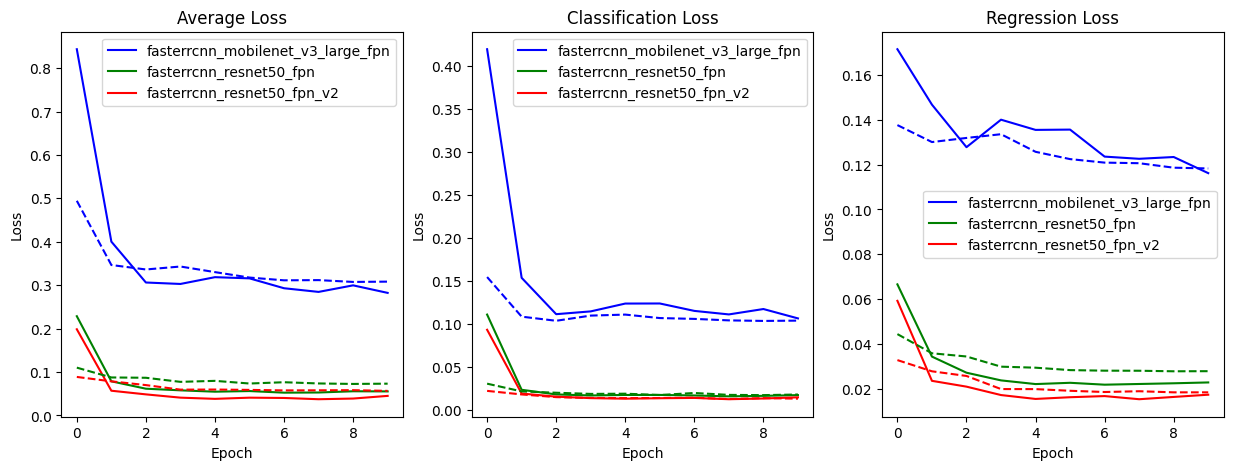

In [4]:
mode = 'train'
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
colors = ['b', 'g', 'r']
model_names = list(results[mode].keys())

for model_name, model_results in results[mode].items():

    # Get the losses
    average_losses = np.array(model_results).squeeze()[:, 0]
    classification_losses = np.array(model_results).squeeze()[:, 1]
    regression_losses = np.array(model_results).squeeze()[:, 2]

    color = colors[model_names.index(model_name)]

    axs[0].plot(average_losses, label=model_name, c=color)
    axs[1].plot(classification_losses, label=model_name, c=color)
    axs[2].plot(regression_losses, label=model_name, c=color)

mode = 'val'
for model_name, model_results in results[mode].items():
    average_losses = np.array(model_results).squeeze()[:, 0]
    classification_losses = np.array(model_results).squeeze()[:, 1]
    regression_losses = np.array(model_results).squeeze()[:, 2]

    color = colors[model_names.index(model_name)]

    axs[0].plot(average_losses, linestyle='--', c=color)   
    axs[1].plot(classification_losses, linestyle='--', c=color)
    axs[2].plot(regression_losses, linestyle='--', c=color)

axs[0].set_title('Average Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].set_title('Classification Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()

axs[2].set_title('Regression Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].legend()

In [5]:
from scripts.dataset import getPositiveImages, ArreysDetectDataset

root = 'data/'

filenames = getPositiveImages(root)

rng = np.random.default_rng(seed=42)
rng.shuffle(filenames)

n_train, n_val = int(0.8 * len(filenames)), int(0.1 * len(filenames))
n_test = len(filenames) - n_train - n_val

train_set = ArreysDetectDataset(root, filenames[:n_train])
val_set = ArreysDetectDataset(root, filenames[n_train:n_train+n_val], train=False)
test_set = ArreysDetectDataset(root, filenames[n_train+n_val:], train=False)

In [14]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes
from torchvision.ops import nms

root = 'dataset/images/dpi100/'

device = get_device()

def compute_random_predictions(model, set):
    model.eval()

    with torch.no_grad():
        x = torch.empty((9, 3, 585, 414))
        y = []
        random_index = np.random.choice(len(set), 9, replace=False)
        for i in range(9):
            x[i] = set.__getitem__(random_index[i])[0]
            y.append(set.__getitem__(random_index[i])[1])
        predictions = model(x.to(device))

    fig, axs = plt.subplots(3, 3, figsize=(15, 20))

    for i in range(9):
        pred = predictions[i]
        image = x[i]
        pred_labels = [f"array: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
        pred_scores = pred["scores"]
        pred_boxes = pred["boxes"]
        keep_indices = torch.arange(len(pred_scores)).to(device)
        keep_indices = nms(pred_boxes, pred_scores, 0.05)
        # keep_indices = keep_indices[pred_scores[keep_indices] > 0.1]
        pred_boxes = pred_boxes[keep_indices]
        pred_labels = [pred_labels[i] for i in keep_indices]
        #image = T.Resize((585, 414))(x[i])

        output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")
        axs[i // 3, i % 3].imshow(output_image.permute(1, 2, 0))
        axs[i // 3, i % 3].scatter(y[i]['boxes'].T[0], y[i]['boxes'].T[1], c='g', s=20, marker='x')
        axs[i // 3, i % 3].scatter(y[i]['boxes'].T[2], y[i]['boxes'].T[3], c='g', s=20, marker='x')
        axs[i // 3, i % 3].axis('off')

In [15]:
def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    xA = max(x1_min, x2_min)
    yA = max(y1_min, y2_min)
    xB = min(x1_max, x2_max)
    yB = min(y1_max, y2_max)

    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    area = interWidth * interHeight

    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union = box1_area + box2_area - area

    return area / union

def compute_iou_matrix(bbox_pred, bbox_gt):
    # Compute the intersection over union of two sets of boxes, each box is [x1, y1, x2, y2]
    N = len(bbox_pred)
    M = len(bbox_gt)
    iou_matrix = np.zeros((N, M))

    for i, pred in enumerate(bbox_pred) :
        for j, gt in enumerate(bbox_gt) :
            iou_matrix[i, j] = compute_iou(pred, gt)
    
    if N == 0 :
        iou_matrix = np.zeros((1, M+1))
        iou_matrix[0, -1] = 1
    elif M == 0 :
        iou_matrix = np.zeros((N+1, 1))
        iou_matrix[-1, 0] = 1
    
    return iou_matrix

In [16]:
def compute_threshold(model, loader, threshold, score_disc, plot=False) :
    n_invented, n_undetected, n_detected = 0, 0, 0
    with torch.no_grad():
        for images, targets in loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
            predictions = model(images)

            for i in range(len(targets)) :
                pred = predictions[i]
                target = targets[i]
                pred_scores = pred["scores"]
                pred_boxes = pred["boxes"]
                keep_indices = torch.arange(len(pred_scores)).to(device)
                keep_indices = nms(pred_boxes, pred_scores, 0.5)
                keep_indices = keep_indices[pred_scores[keep_indices] > score_disc]
                pred_boxes = pred_boxes[keep_indices]
                gt_boxes = target['boxes']

                iou_matrix = compute_iou_matrix(pred_boxes, gt_boxes)

                inventions = np.count_nonzero(np.max(iou_matrix, axis=1) ==0)
                undetected = np.count_nonzero(np.max(iou_matrix, axis=0) < threshold)
                detected = np.count_nonzero(np.max(iou_matrix, axis=0) > threshold)

                n_invented += inventions
                n_undetected += undetected
                n_detected += detected

                if plot :
                    if inventions or undetected :
                        image = images[i]
                        pred_boxes = pred["boxes"]
                        pred_colors = ['red' for _ in range(len(pred_boxes))]
                        gt_colors = ['green' for _ in range(len(gt_boxes))]
                        output_image = draw_bounding_boxes(image, torch.cat([pred_boxes, gt_boxes]), colors=pred_colors + gt_colors)
                        print('sample : ' + str(i))
                        print(f'iou_matrix : {iou_matrix}')
                        print(f'predicted_scores : {pred_scores}')
                        plt.imshow(output_image.permute(1, 2, 0))
                        plt.axis('off')
                        plt.show()

    return n_invented, n_undetected, n_detected

## Visualizing model performances

### MobileNet v3 backbone

In [17]:
from scripts.models import get_model_object_detection
from torch.utils.data import DataLoader

from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, fasterrcnn_resnet50_fpn_v2
import torch
model = get_model_object_detection(fasterrcnn_mobilenet_v3_large_fpn(trainable_backbone_layers=2), 2)
model.load_state_dict(torch.load('models/fasterrcnn_mobilenet_v3_large_fpn_model.pth', map_location=device))
model.to(device)

test_loader = DataLoader(test_set, batch_size=20, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=20, shuffle=True, collate_fn=collate_fn)

/tmp/ipykernel_1312/3492957742.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('models/fasterrcnn_mobilenet_v3_large_fpn_model.pth', map

On the following plots, red boxes indicate model's predictions and green crosses the ground truth corners.

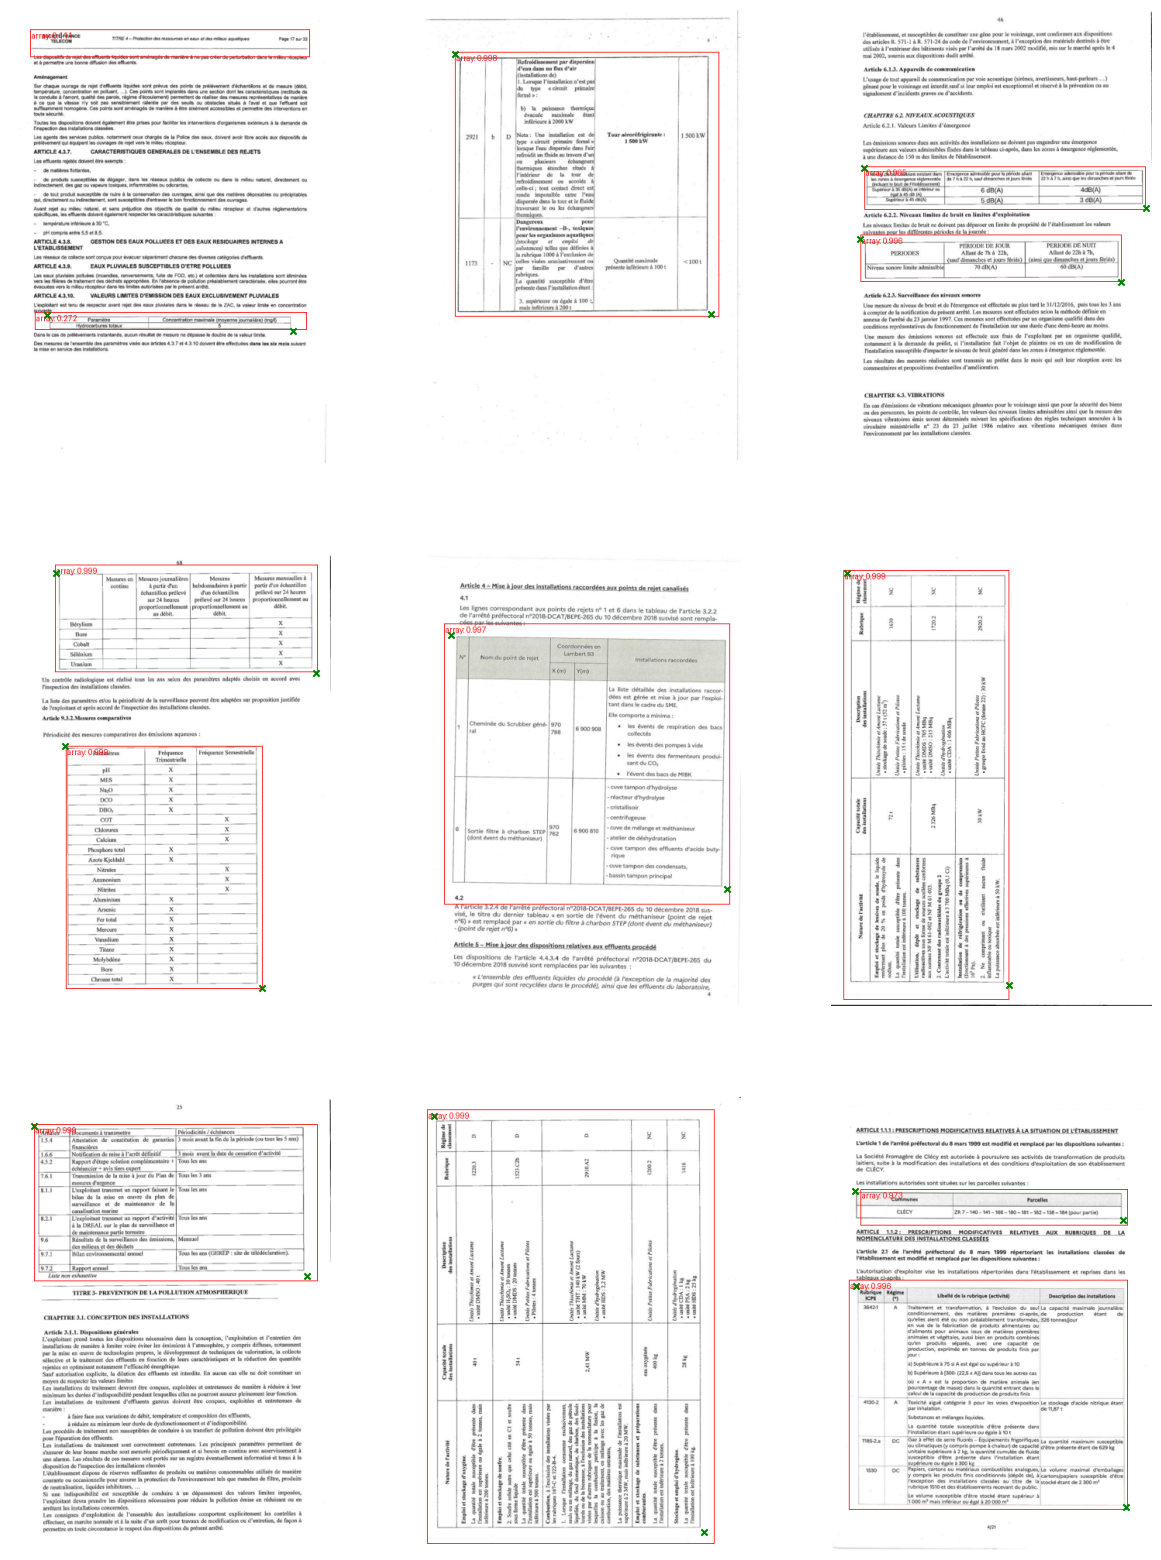

In [18]:
compute_random_predictions(model, val_set)

In [21]:
thresholds = np.linspace(0.2, 0.8, 10)
score_discs = np.linspace(0.7, 0.99, 10)
grid = np.meshgrid(score_discs, thresholds)
output = np.zeros((len(thresholds), len(score_discs), 3))
for i, threshold in enumerate(thresholds) :
    for j, score_disc in enumerate(score_discs) :
        output[i, j] = compute_threshold(model, val_loader, threshold, score_disc)

Text(0.5, 1.0, 'Missed arrays (color) and invented arrays (point size) on the validation set.')

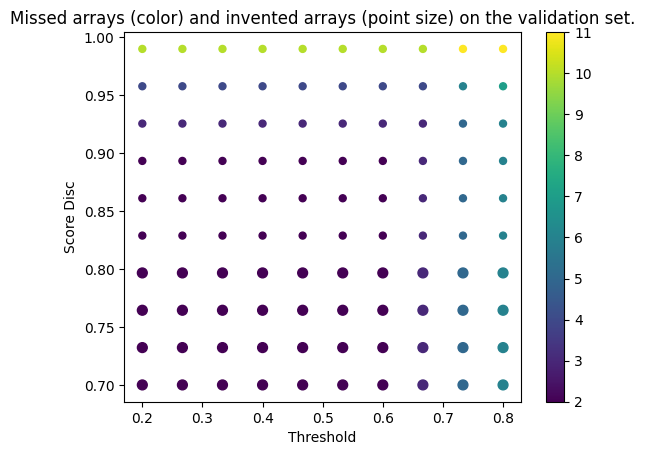

In [20]:
plt.scatter(grid[1], grid[0], s=(output[:, :, 0]+1) * 25, c=output[:, :, 1], label='Invented')
plt.colorbar()
plt.ylabel('Score Disc')
plt.xlabel('Threshold')
plt.title('Missed arrays (color) and invented arrays (point size) on the validation set.')

sample : 15
iou_matrix : [[0. 1.]]
predicted_scores : tensor([0.2722, 0.1110, 0.0753], device='cuda:0', grad_fn=<IndexBackward0>)


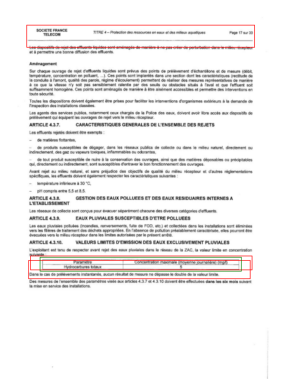

sample : 8
iou_matrix : [[0.92644835]
 [0.        ]]
predicted_scores : tensor([0.9986, 0.8142], device='cuda:0', grad_fn=<IndexBackward0>)


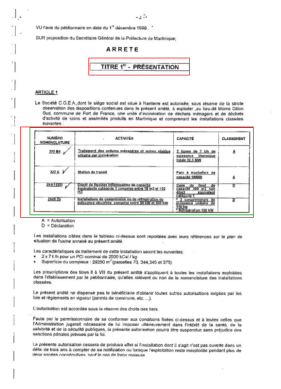

(1, 1, 41)

In [20]:
compute_threshold(model, 0.5, 0.5, plot=True)

In [31]:
torch.cuda.empty_cache()

### Resnet50 backbone

In [14]:
model = get_model_object_detection(fasterrcnn_resnet50_fpn_v2(trainable_backbone_layers=2), 2)
model.load_state_dict(torch.load('models/fasterrcnn_resnet50_fpn_v2_model.pth', map_location=device))
model.to(device)

test_loader = DataLoader(test_set, batch_size=5, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=5, shuffle=True, collate_fn=collate_fn)

/Users/camsz/miniconda3/envs/pytorch_env/lib/python3.12/site-packages/torchvision/models/detection/backbone_utils.py:162: UserWarning: Changing trainable_backbone_layers has no effect if neither pretrained nor pretrained_backbone have been set to True, falling back to trainable_backbone_layers=5 so that all layers are trainable
  warnings.warn(


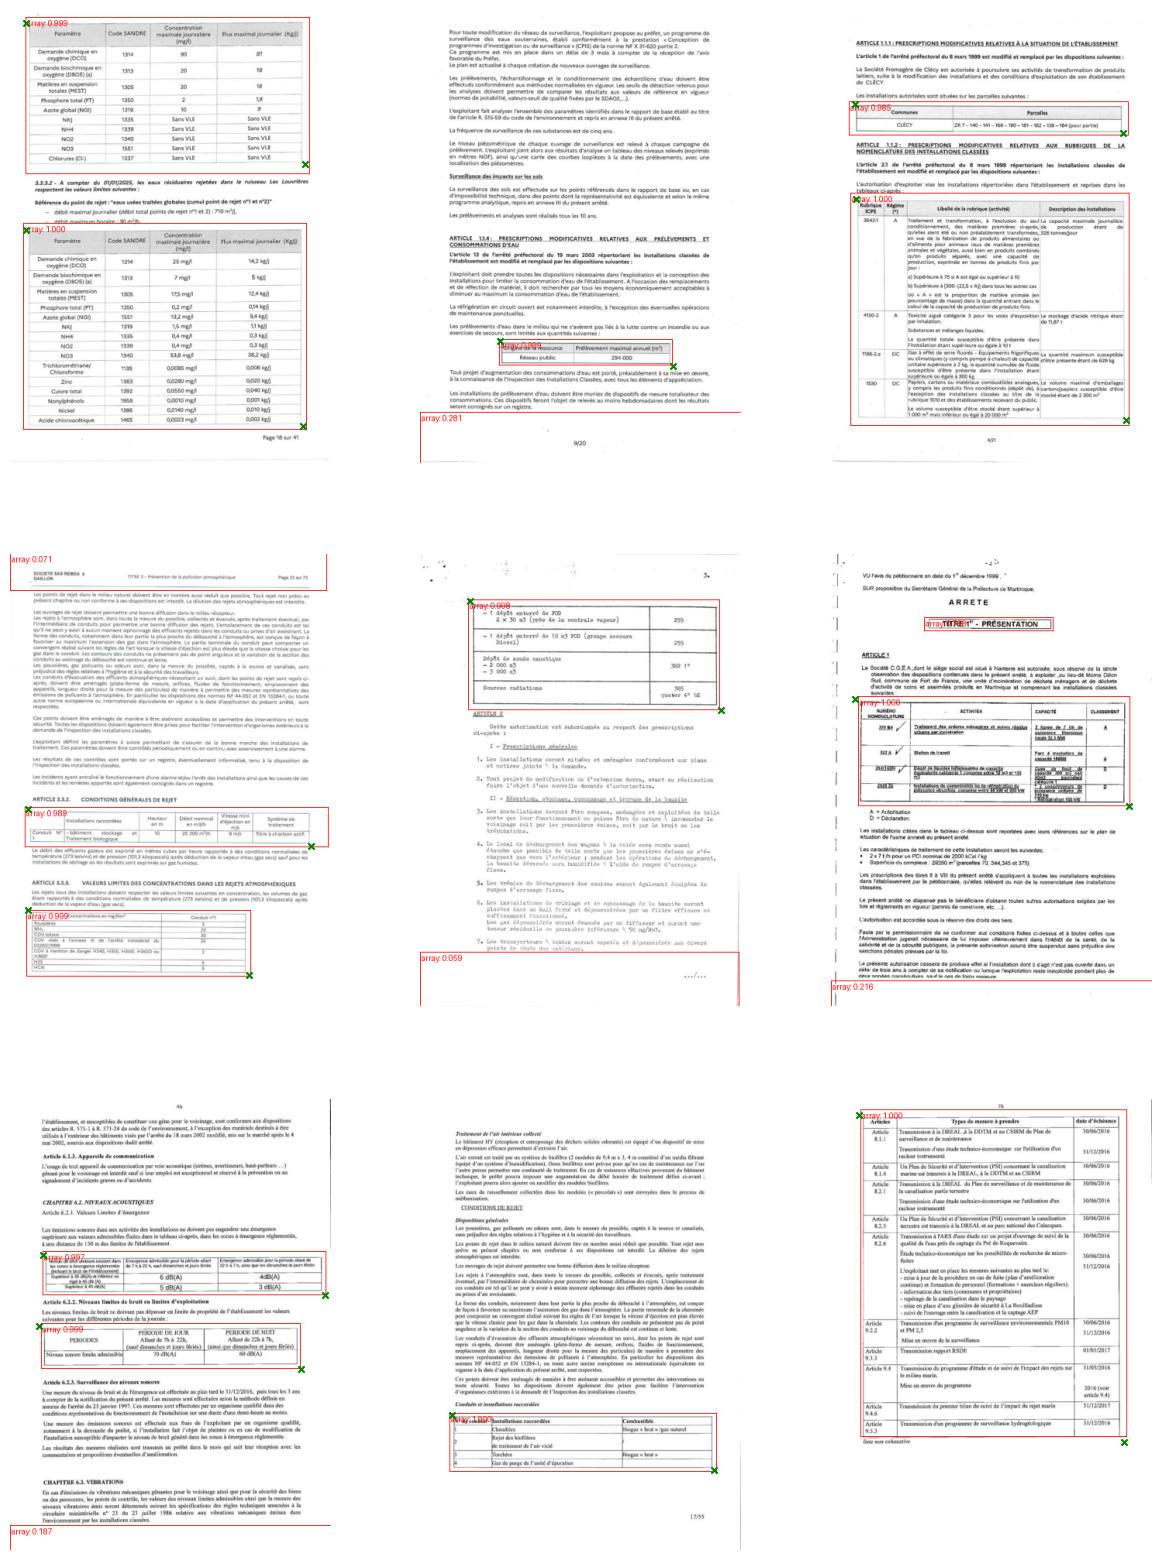

In [11]:
compute_random_predictions(model, val_set)

In [15]:
thresholds = np.linspace(0.2, 0.8, 10)
score_discs = np.linspace(0.7, 0.99, 10)
grid = np.meshgrid(score_discs, thresholds)
output = np.zeros((len(thresholds), len(score_discs), 3))
for i, threshold in enumerate(thresholds) :
    for j, score_disc in enumerate(score_discs) :
        output[i, j] = compute_threshold(model, val_loader, threshold, score_disc)

AssertionError: targets should not be none when in training mode

Text(0.5, 0, 'Threshold')

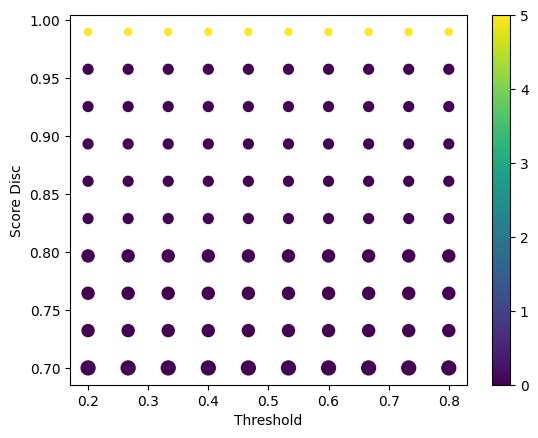

In [18]:
plt.scatter(grid[1], grid[0], s=(output[:, :, 0]+1) * 25, c=output[:, :, 1], label='Invented')
plt.colorbar()
plt.ylabel('Score Disc')
plt.xlabel('Threshold')

sample : 2
iou_matrix : [[0.90182108]
 [0.        ]]
predicted_scores : tensor([0.9983, 0.9647, 0.0701, 0.0531], device='cuda:0')


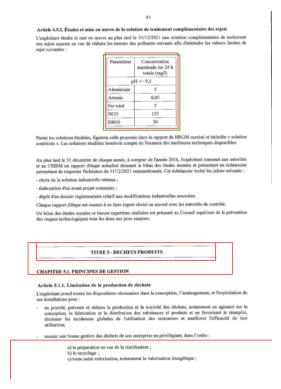

(1, 0, 41)

In [14]:
compute_threshold(model, val_loader, 0.5, 0.8, plot=True)